# 03 - Analyse finale de Lmaana 2.1

> Notebook 3/3 du rapport final.

Ce notebook ne lance aucun entraînement. Il rassemble les métriques finales, l’évolution version par version, les figures, les différences entre datasets et les exemples de transcription V5/Lmaana 2.1.

In [24]:
from pathlib import Path
import json
import subprocess
import sys

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

import pandas as pd
from IPython.display import Image, Markdown, display
from scripts.plot_lmaana_2_1_results import TEST, VALIDATION

OUTPUTS = PROJECT / 'outputs'
REPORTS = PROJECT / 'reports'
FIGURES = PROJECT / 'model_cards/assets/lmaana-2.1'
SELECTION = OUTPUTS / 'lmaana_clean_selections/long.json'
print('Projet :', PROJECT)
if SELECTION.is_file():
    selected = json.loads(SELECTION.read_text(encoding='utf-8'))['selected']
    print('Checkpoint sélectionné : step', selected['step'])
    print(selected['checkpoint'])

Projet : /home/skiredj.abderrahman/badr/darija-ctc-lmaana
Checkpoint sélectionné : step 5000
/home/skiredj.abderrahman/badr/darija-ctc-lmaana/outputs/lmaana_clean_v5_long/ws_1.bd2f3081/checkpoints/step_5000/model/pp_00/tp_00/sdp_00.pt


## 1. Protocole final

La sélection repose uniquement sur validation. Le test est évalué une seule fois après la sélection. Dataset13 et Lmaana clean sont affichés séparément. Avec le tokenizer écrit utilisé ici, UER est présenté comme CER/UER.

In [25]:
validation_rows = []
for step, datasets in VALIDATION.items():
    model = 'Retained V5' if step == 0 else ('Lmaana 2.1' if step == 5000 else f'Step {step}')
    for dataset, metrics in datasets.items():
        validation_rows.append({
            'split': 'validation', 'step': step, 'model': model, 'dataset': dataset,
            'CER/UER': metrics['cer'], 'WER': metrics['wer'],
        })
validation = pd.DataFrame(validation_rows)

test_rows = []
for model, datasets in TEST.items():
    for dataset, metrics in datasets.items():
        test_rows.append({
            'split': 'test', 'model': model, 'dataset': dataset,
            'CER/UER': metrics['cer'], 'WER': metrics['wer'],
        })
test = pd.DataFrame(test_rows)
display(validation)
display(test)

,split,step,model,dataset,CER/UER,WER
0,validation,0,Retained V5,Dataset13,17.3908,43.2622
1,validation,0,Retained V5,Lmaana clean,13.1994,40.4155
2,validation,3500,Step 3500,Dataset13,17.3347,43.1245
3,validation,3500,Step 3500,Lmaana clean,13.2053,40.4015
4,validation,5000,Lmaana 2.1,Dataset13,17.3252,43.1238
5,validation,5000,Lmaana 2.1,Lmaana clean,13.1925,40.3535


,split,model,dataset,CER/UER,WER
0,test,Retained V5,Dataset13,17.7674,44.2243
1,test,Retained V5,Lmaana clean,14.6099,45.1385
2,test,Lmaana 2.1,Dataset13,17.7029,44.0393
3,test,Lmaana 2.1,Lmaana clean,14.6048,45.1690


## 2. Écart final par rapport à V5

Une valeur négative est une amélioration.

In [26]:
pivot = test.pivot(index='dataset', columns='model', values=['CER/UER', 'WER'])
deltas = pd.DataFrame(index=pivot.index)
deltas['CER/UER delta'] = pivot[('CER/UER', 'Lmaana 2.1')] - pivot[('CER/UER', 'Retained V5')]
deltas['WER delta'] = pivot[('WER', 'Lmaana 2.1')] - pivot[('WER', 'Retained V5')]
display(deltas.style.format('{:+.4f}'))

,CER/UER delta,WER delta
dataset,,
Dataset13,-0.0645,-0.1850
Lmaana clean,-0.0051,+0.0305


## 3. Génération des figures

Les six figures couvrent le profil des datasets, la progression et le compromis de validation, la comparaison test, les deltas et l’évolution des versions. La figure historique sépare les protocoles MoulSot original et Lmaana clean.

Saved /home/skiredj.abderrahman/badr/darija-ctc-lmaana/model_cards/assets/lmaana-2.1/version_progression.png
Saved /home/skiredj.abderrahman/badr/darija-ctc-lmaana/model_cards/assets/lmaana-2.1/dataset_profile.png
Saved /home/skiredj.abderrahman/badr/darija-ctc-lmaana/model_cards/assets/lmaana-2.1/validation_progress.png
Saved /home/skiredj.abderrahman/badr/darija-ctc-lmaana/model_cards/assets/lmaana-2.1/validation_tradeoff.png
Saved /home/skiredj.abderrahman/badr/darija-ctc-lmaana/model_cards/assets/lmaana-2.1/test_comparison.png
Saved /home/skiredj.abderrahman/badr/darija-ctc-lmaana/model_cards/assets/lmaana-2.1/test_deltas.png


### Version Progression

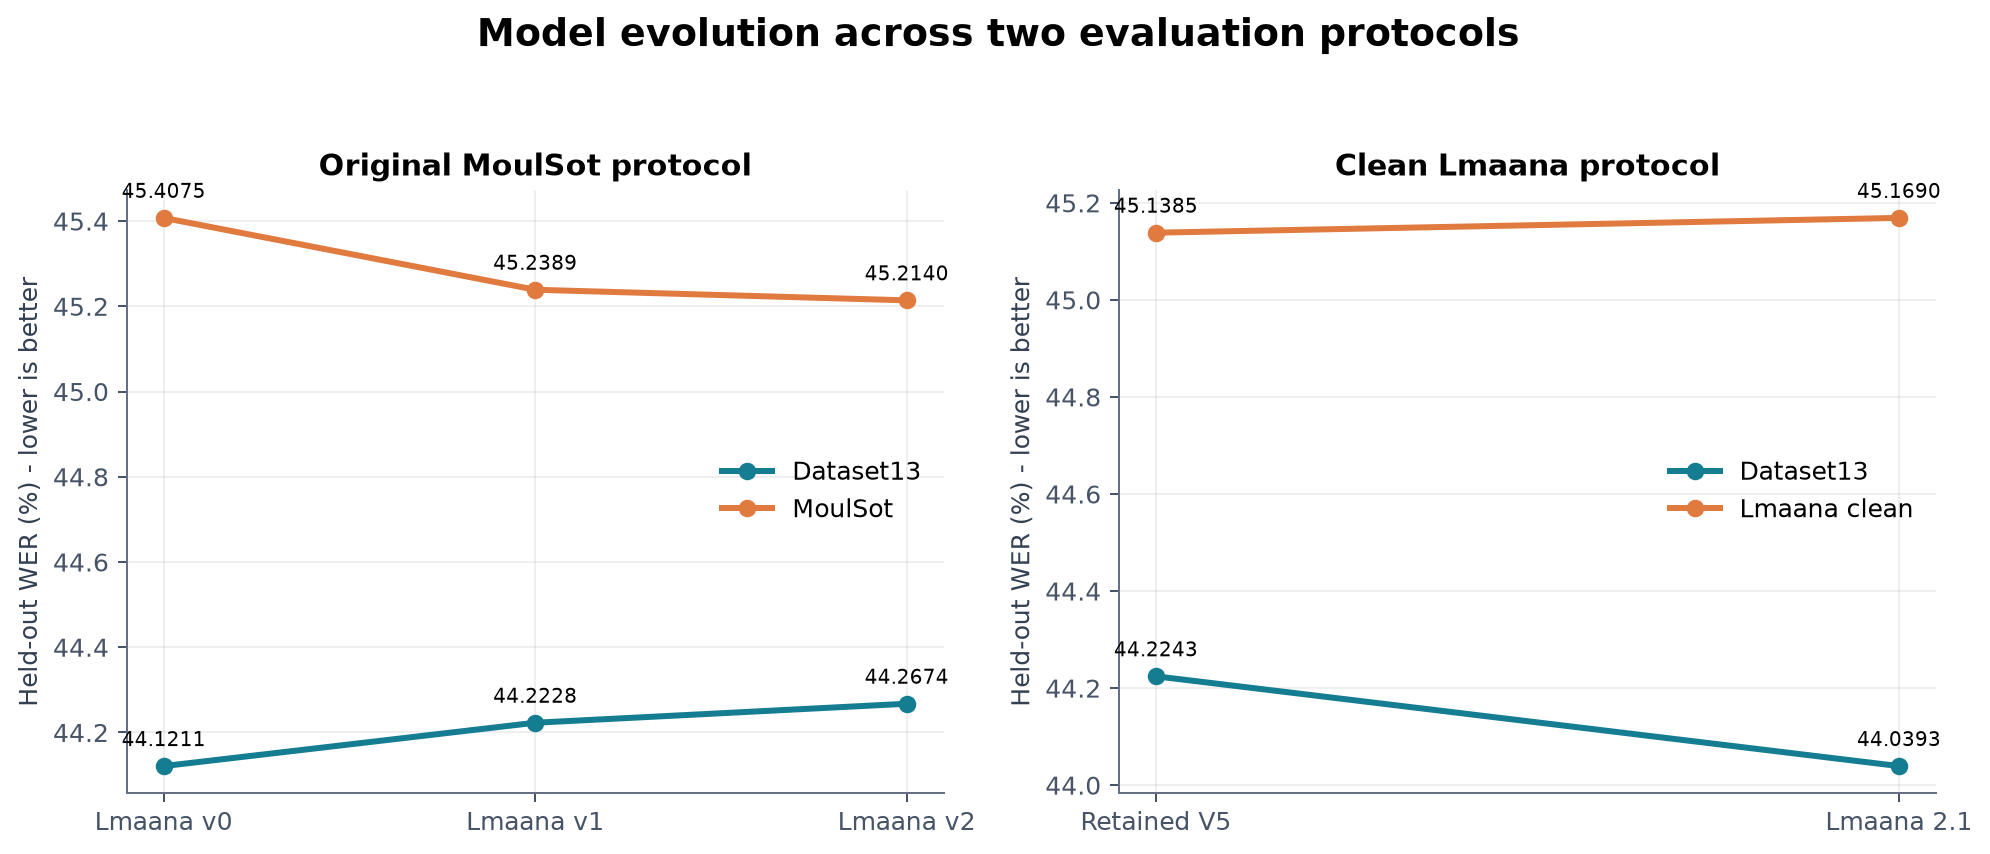

### Dataset Profile

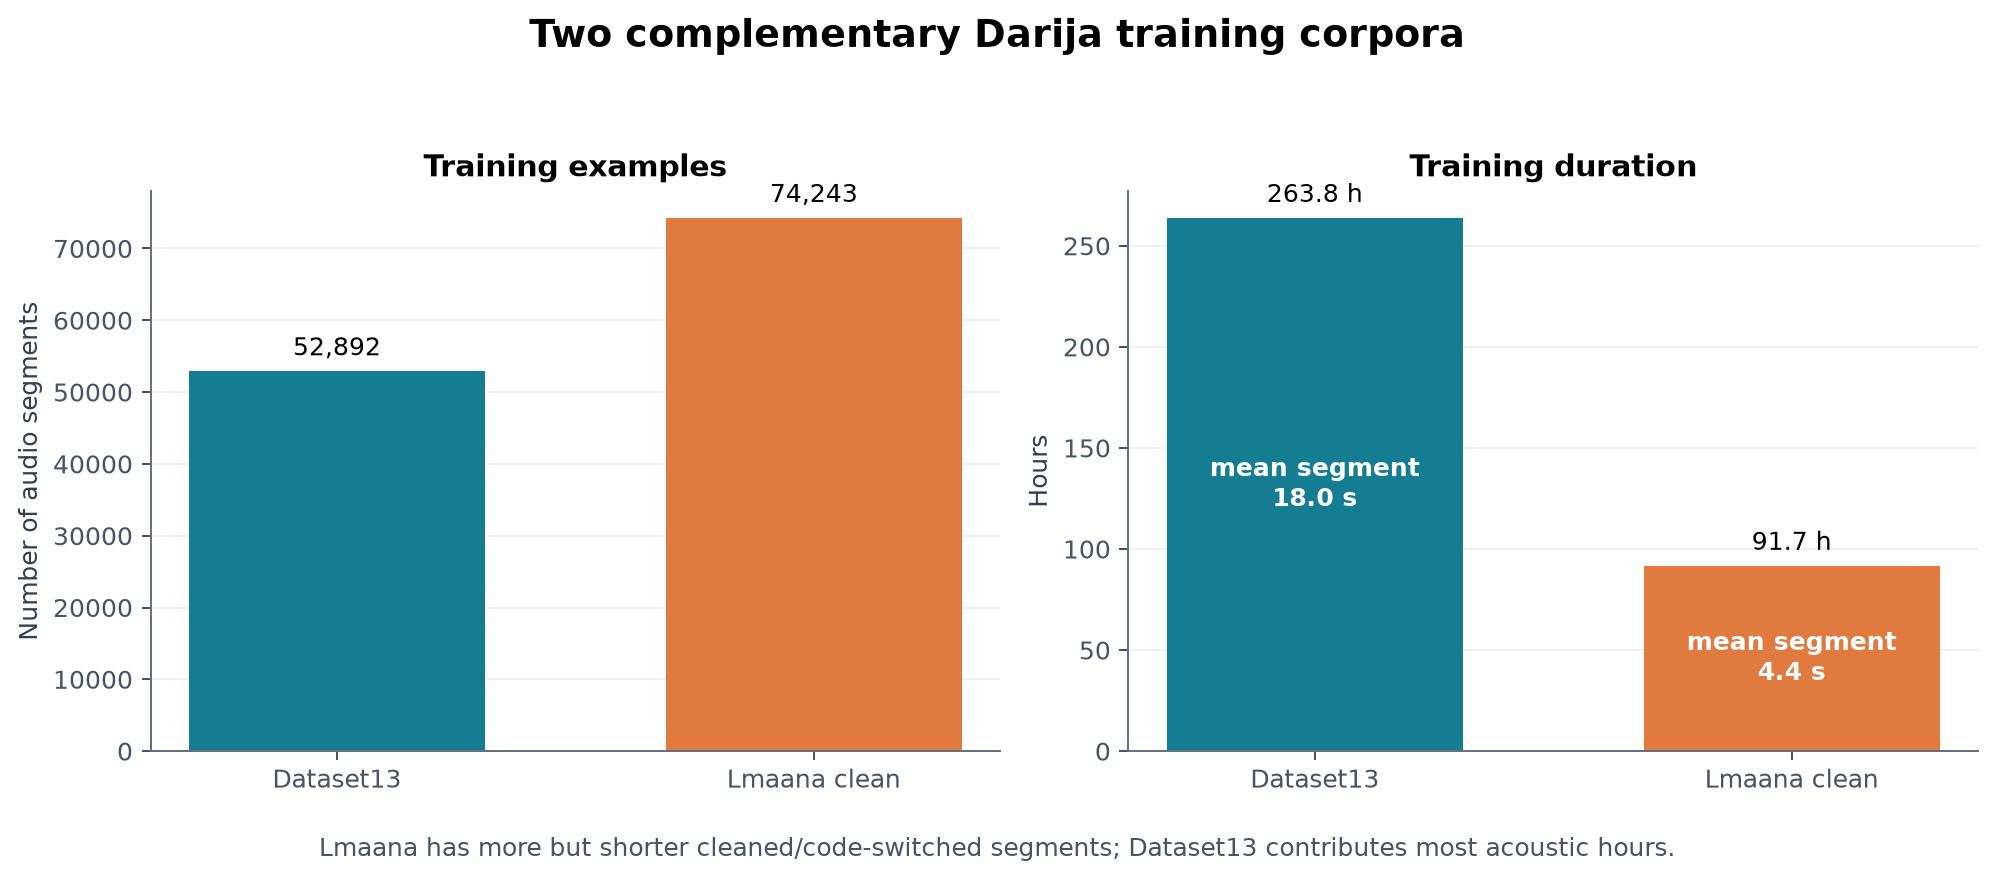

### Validation Progress

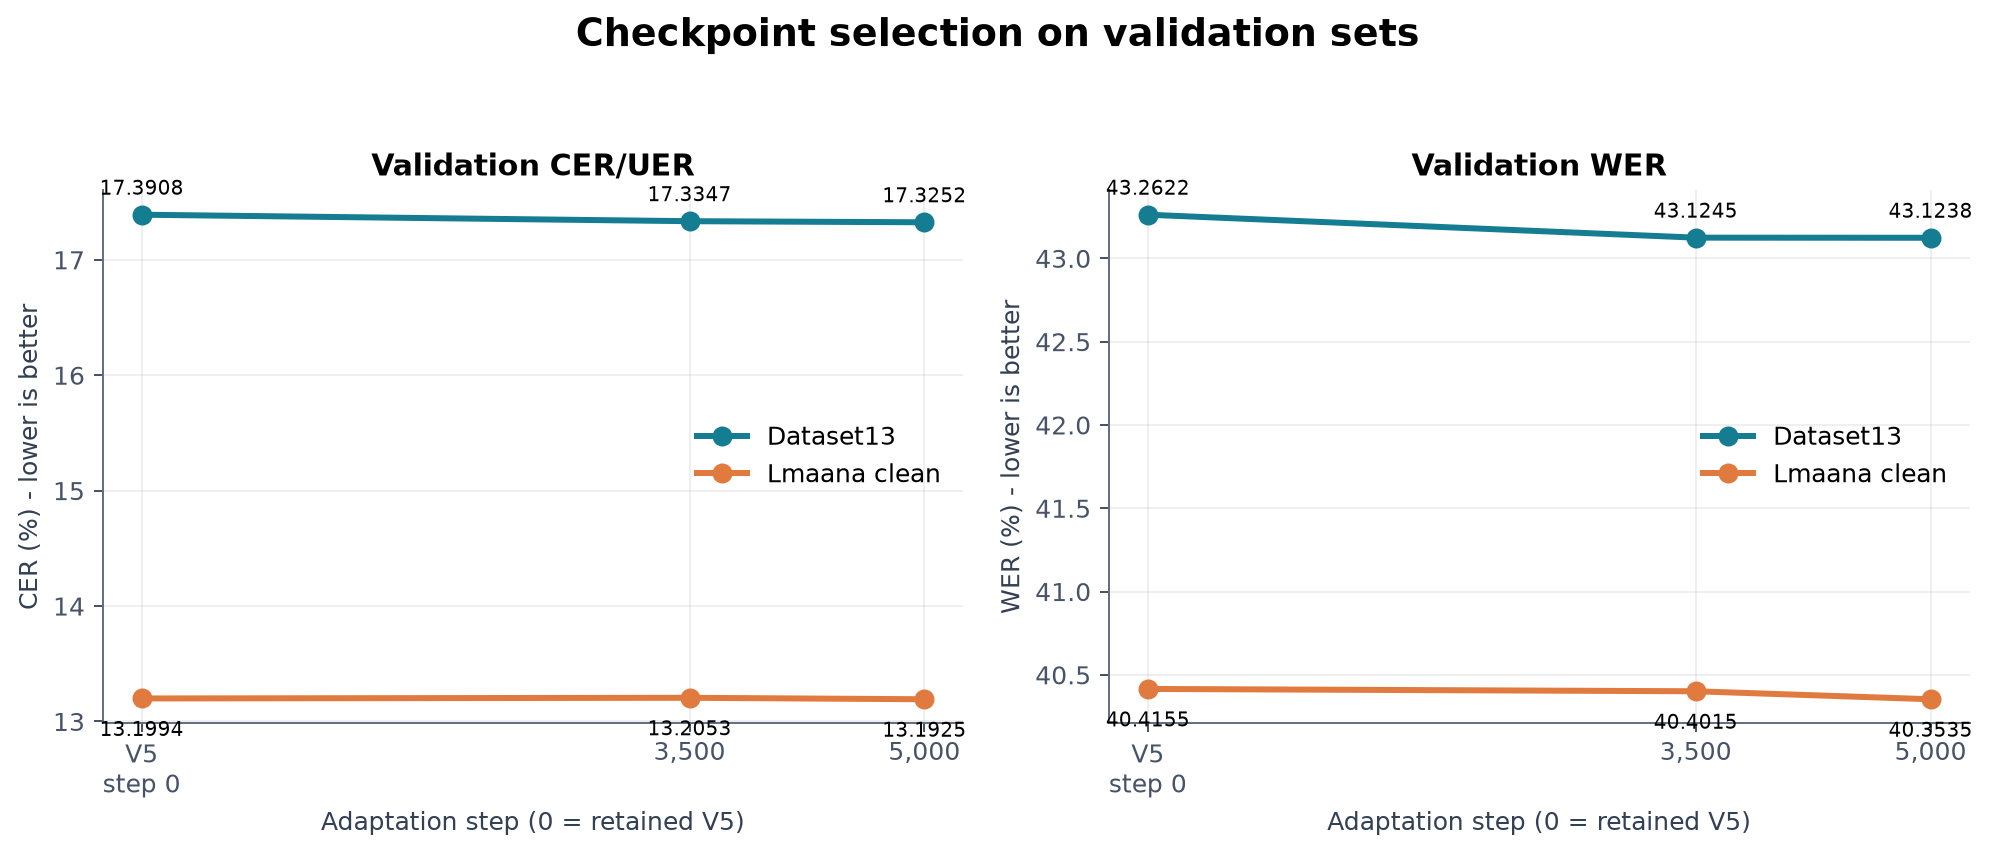

### Validation Tradeoff

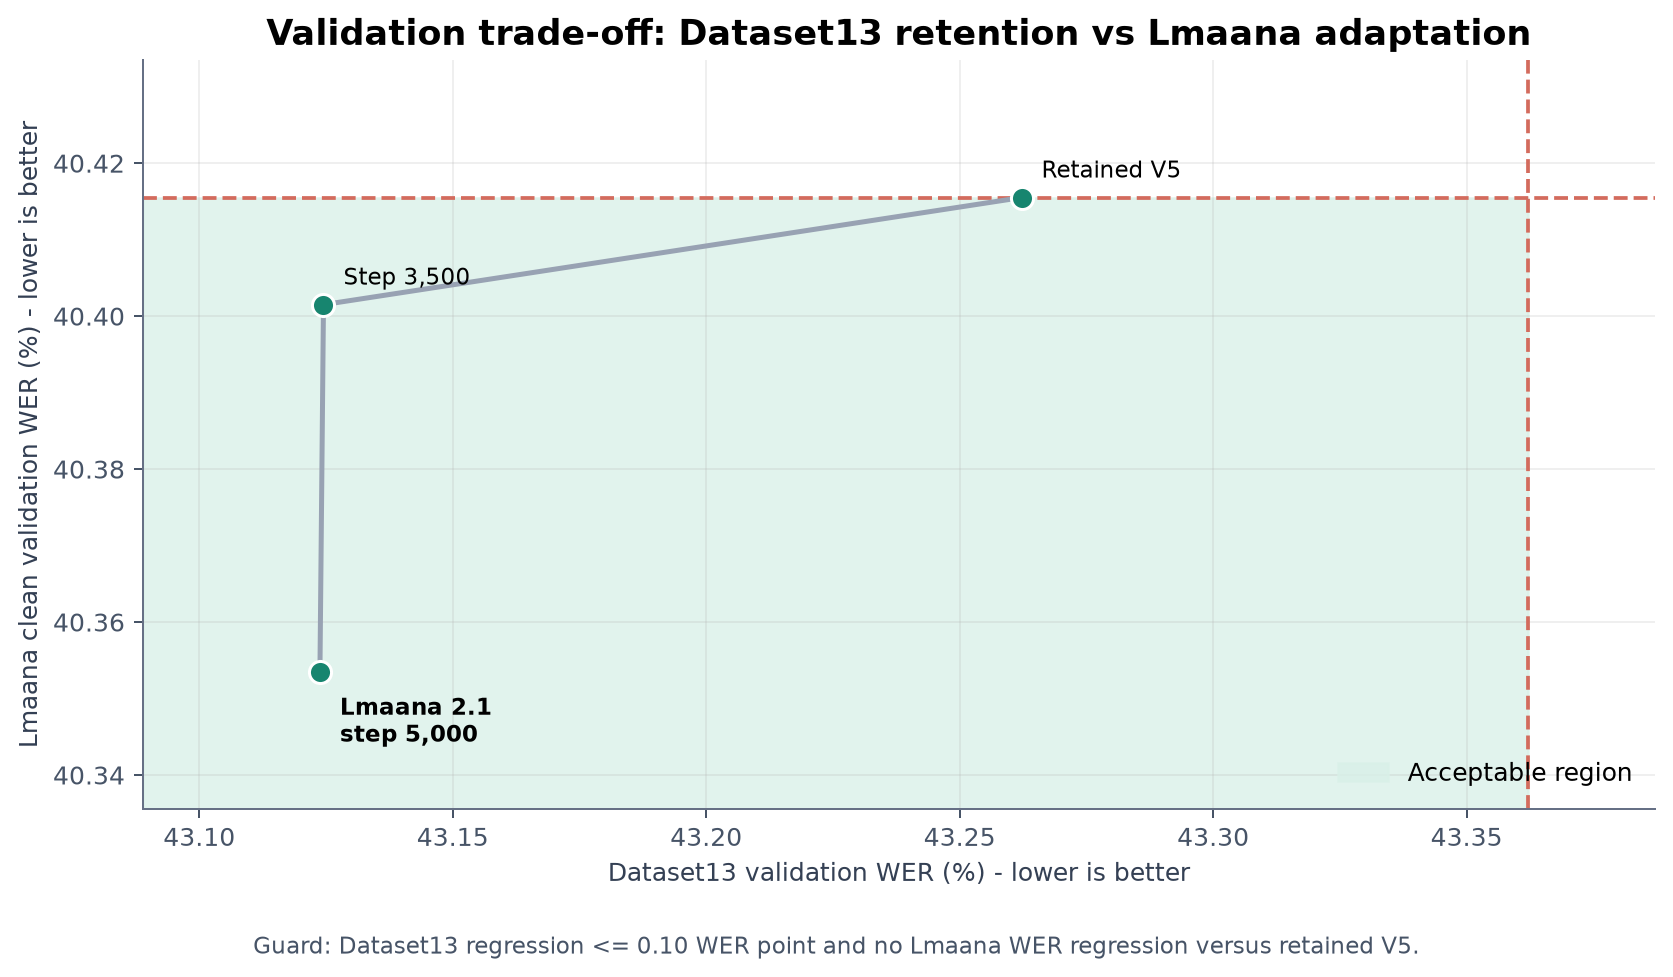

### Test Comparison

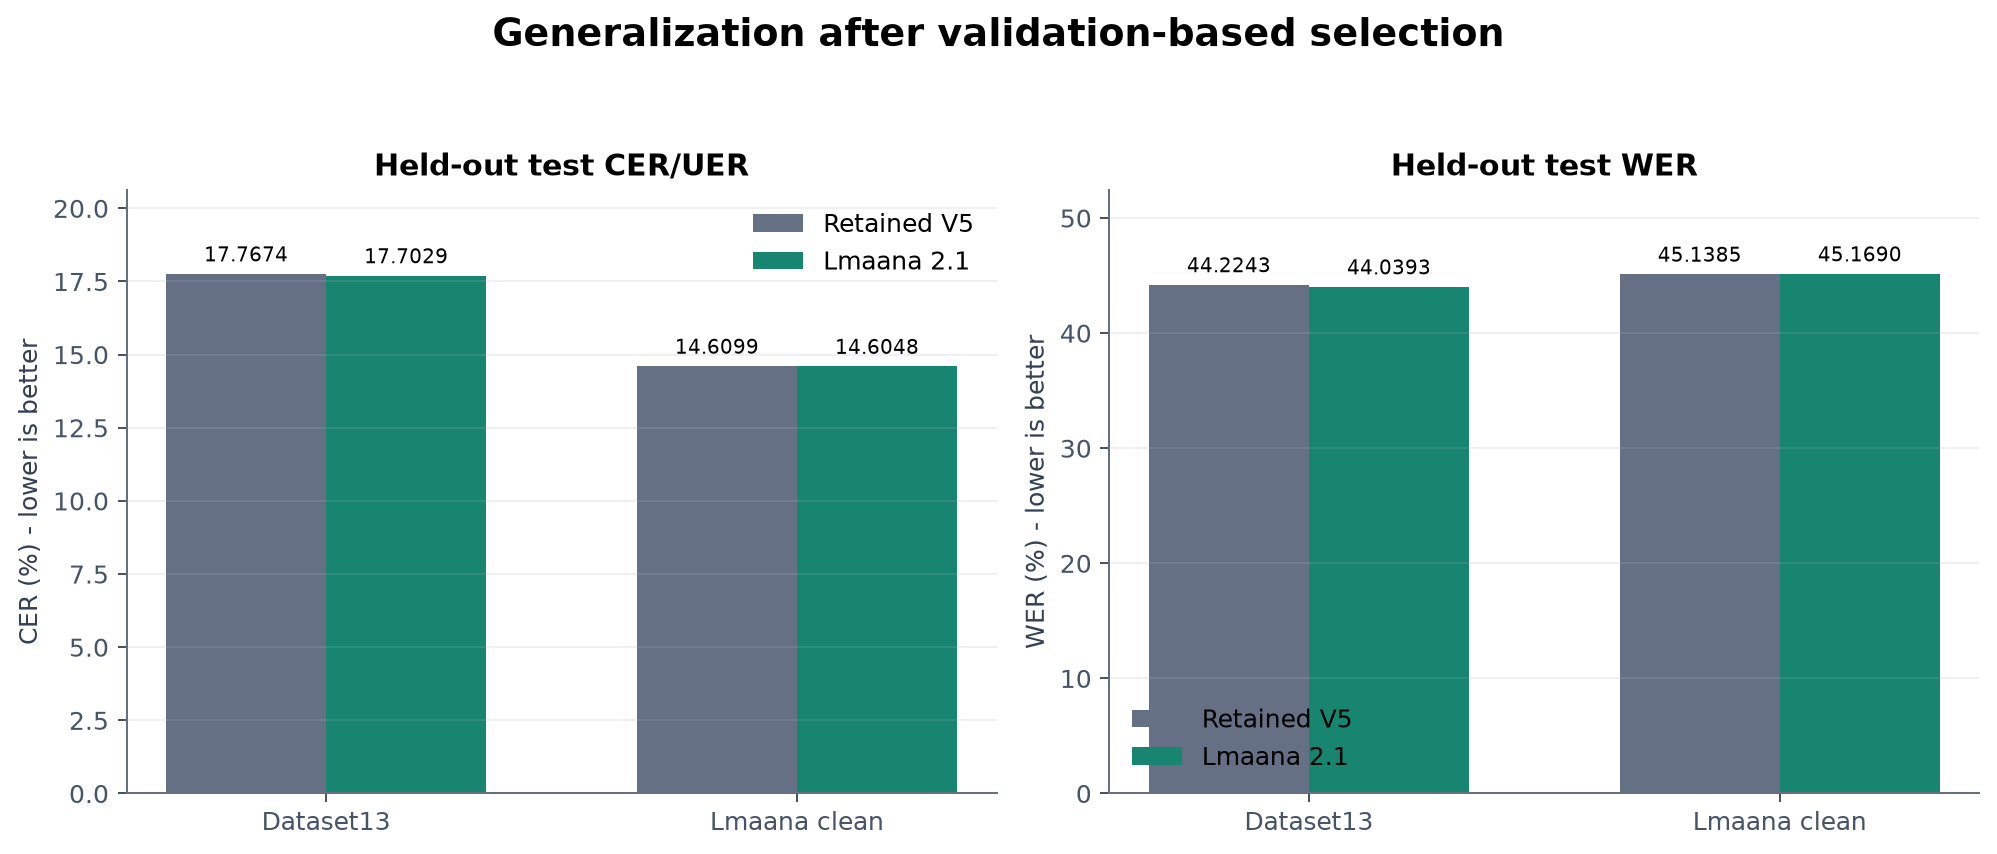

### Test Deltas

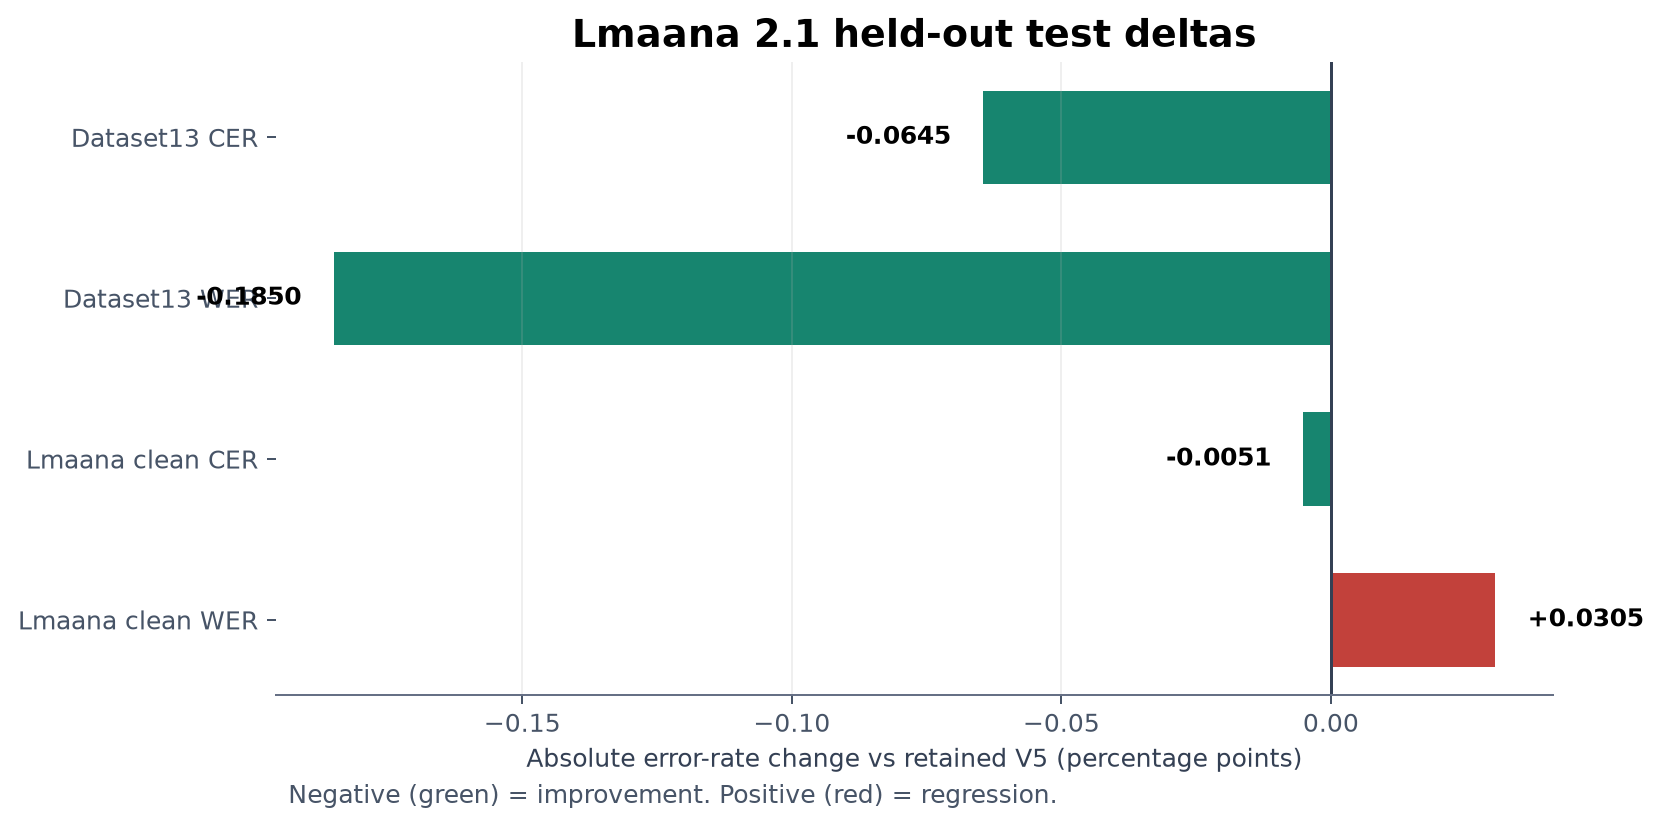

In [27]:
subprocess.run([sys.executable, 'scripts/plot_lmaana_2_1_results.py'], cwd=PROJECT, check=True)
figure_names = [
    'version_progression.png',
    'dataset_profile.png',
    'validation_progress.png',
    'validation_tradeoff.png',
    'test_comparison.png',
    'test_deltas.png',
]
for name in figure_names:
    title = name.replace('_', ' ').replace('.png', '').title()
    display(Markdown(f'### {title}'))
    display(Image(filename=str(FIGURES / name)))

## 4. Loss, learning rate et comparaison des processus

Ces courbes sont extraites du journal fairseq2 de l'adaptation longue et des évaluations de checkpoints. La comparaison distingue le curriculum depuis OmniASR, le recovery depuis V5 et l'adaptation longue depuis V5.

Saved /home/skiredj.abderrahman/badr/darija-ctc-lmaana/model_cards/assets/lmaana-2.1/training_ctc_loss.png
Saved /home/skiredj.abderrahman/badr/darija-ctc-lmaana/model_cards/assets/lmaana-2.1/training_learning_rate.png
Saved /home/skiredj.abderrahman/badr/darija-ctc-lmaana/model_cards/assets/lmaana-2.1/experiment_process_comparison.png


### Training Ctc Loss

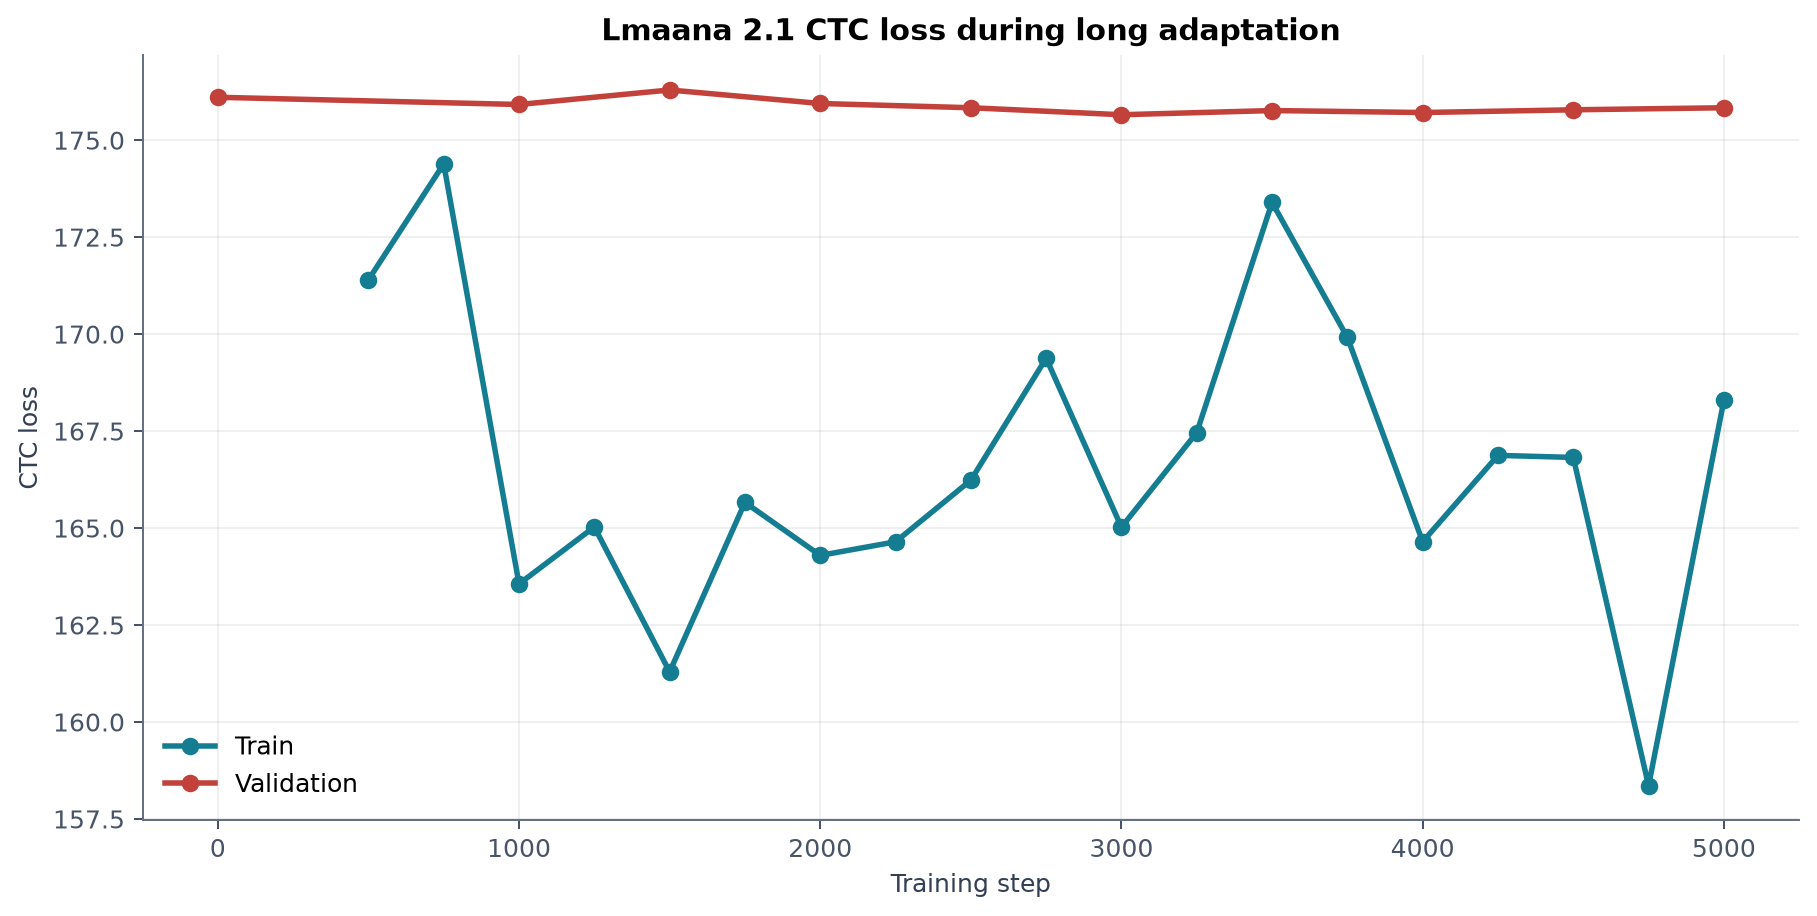

### Training Learning Rate

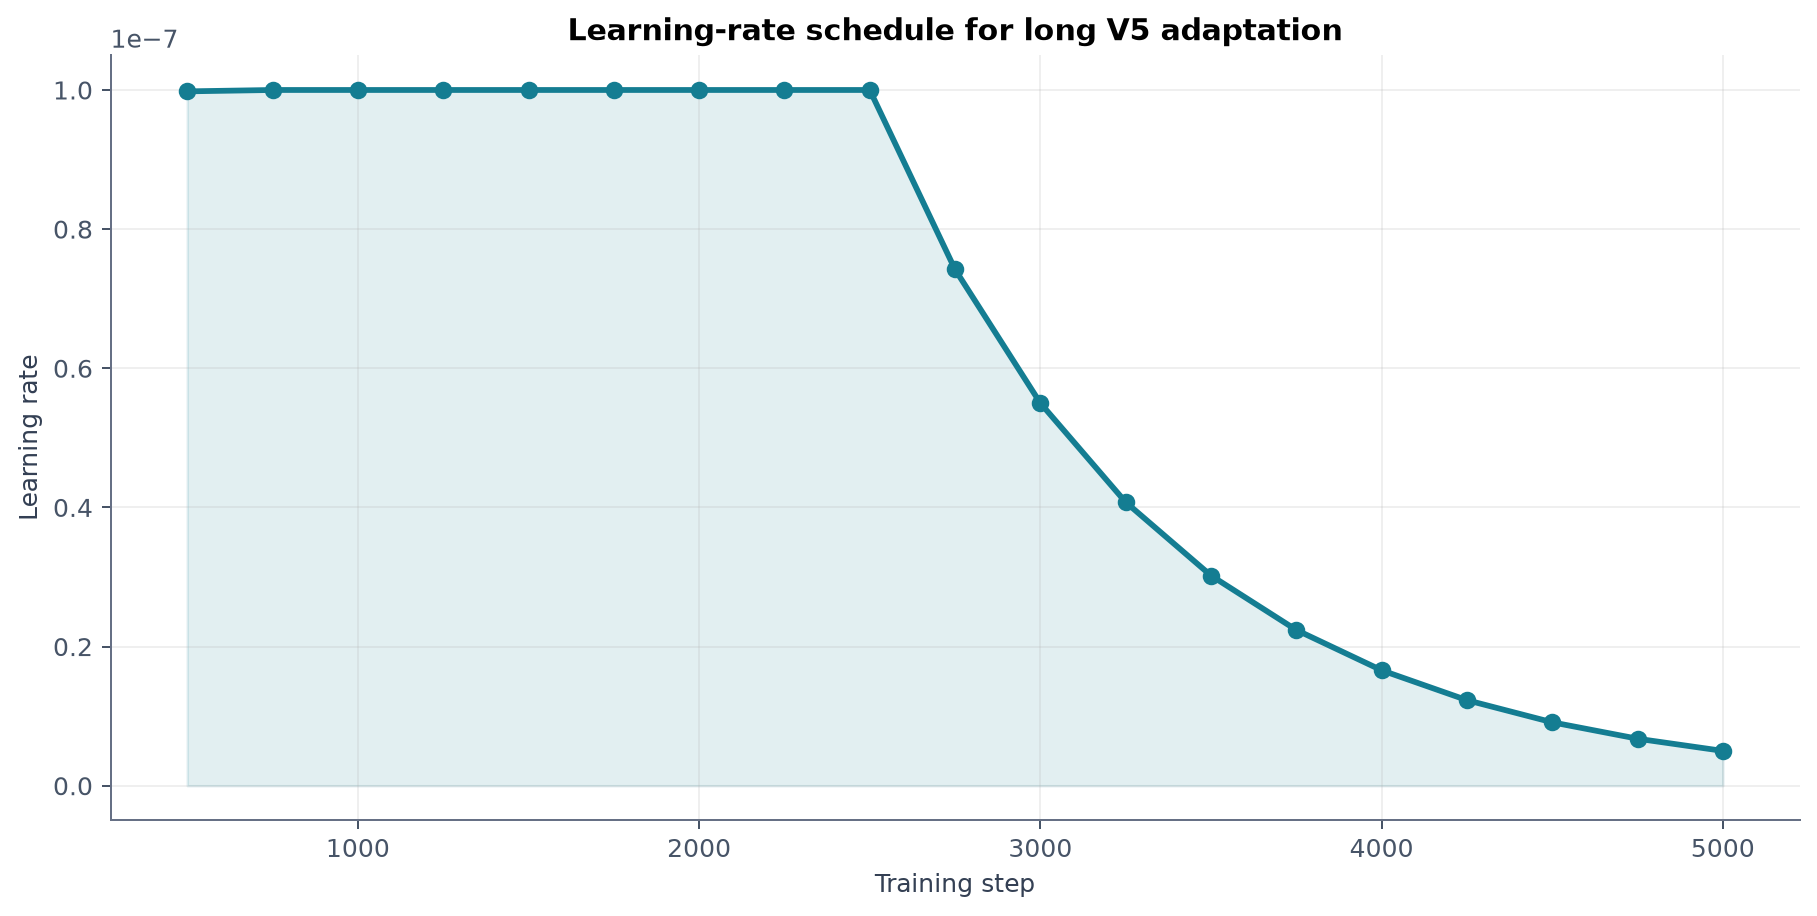

### Experiment Process Comparison

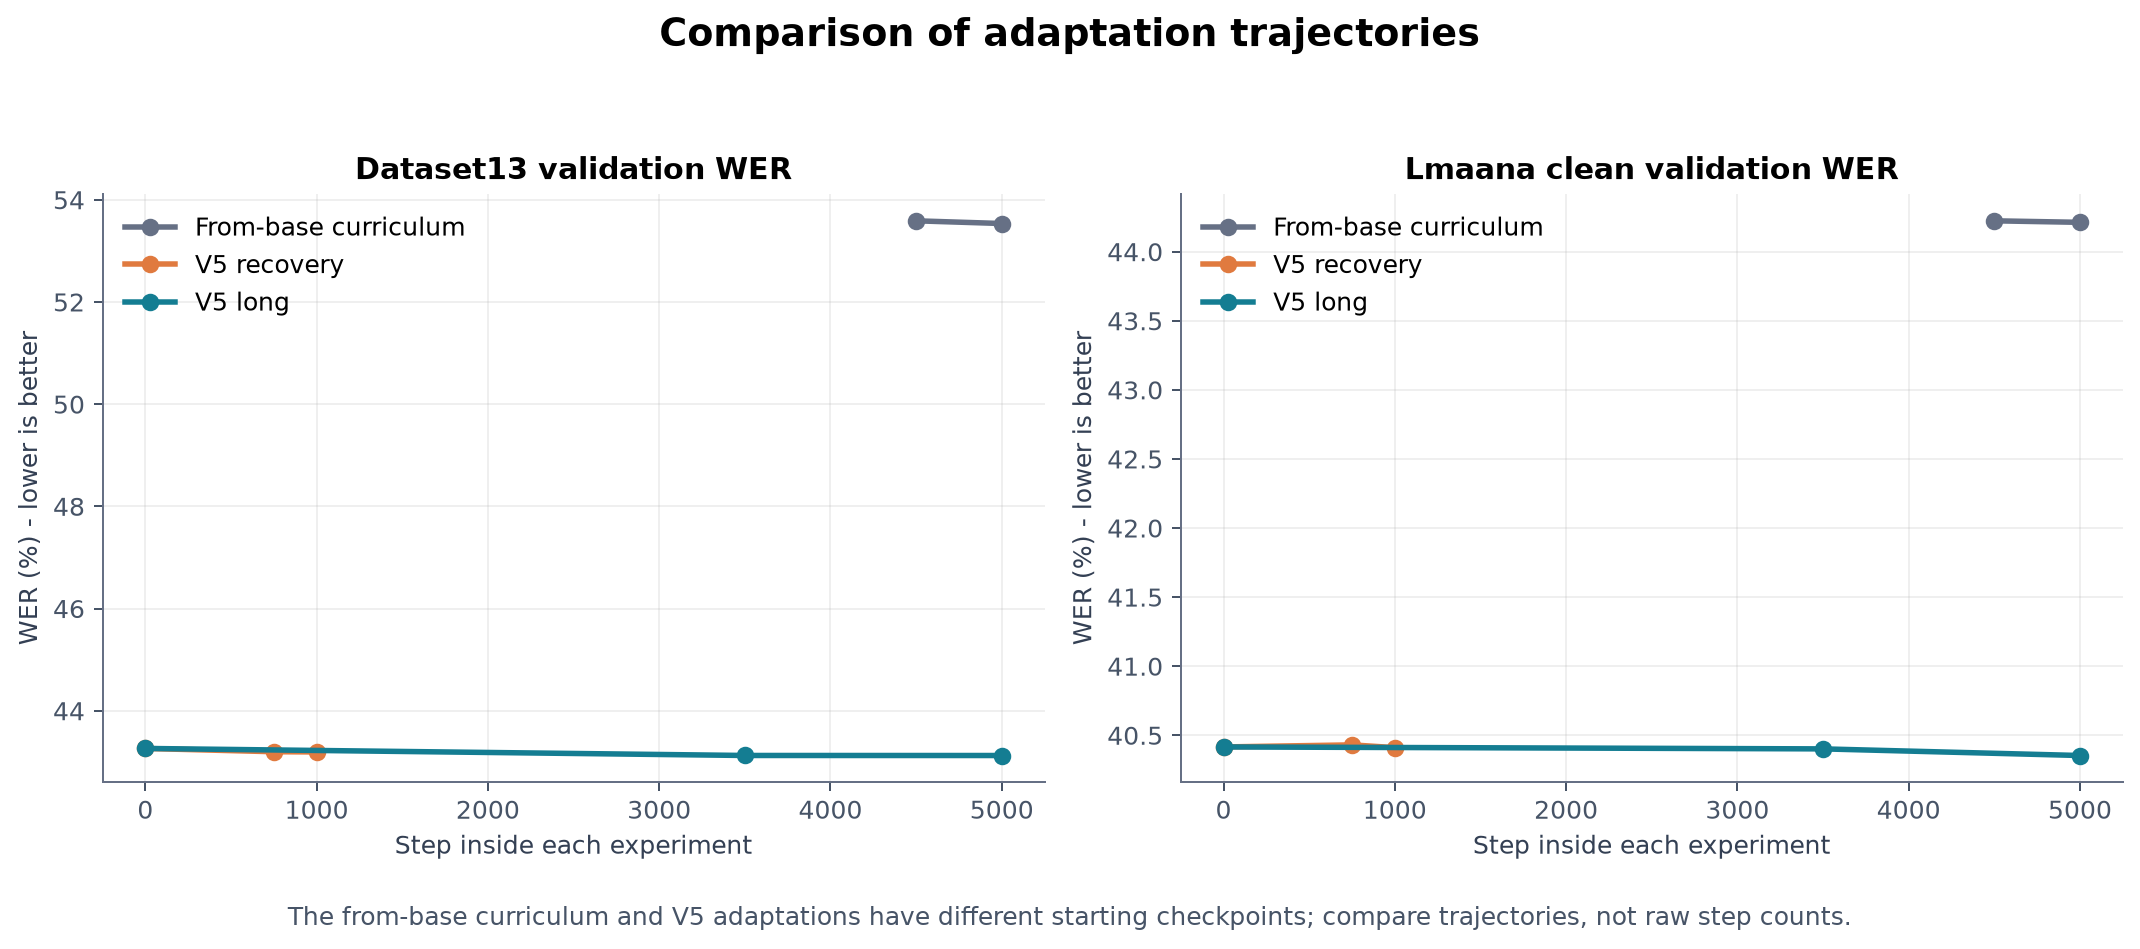

In [28]:
dynamics_log = OUTPUTS / 'lmaana_clean_v5_long.log'
if dynamics_log.is_file():
    subprocess.run([
        sys.executable, 'scripts/plot_lmaana_2_1_training_dynamics.py',
        '--log', str(dynamics_log),
        '--evaluations-root', str(OUTPUTS / 'checkpoint_evaluations'),
        '--output-dir', str(FIGURES),
    ], cwd=PROJECT, check=True)
    for name in (
        'training_ctc_loss.png',
        'training_learning_rate.png',
        'experiment_process_comparison.png',
    ):
        path = FIGURES / name
        if path.is_file():
            display(Markdown(f"### {name.replace('_', ' ').replace('.png', '').title()}"))
            display(Image(filename=str(path)))
else:
    print('Journal HPC absent sur cette machine :', dynamics_log)

## 5. Analyse globale des transcriptions

Le script compare les hypothèses V5 et Lmaana 2.1 sur exactement les mêmes références de test. Il compte les exemples améliorés, régressés et inchangés, puis sélectionne des candidats pour une vérification audio manuelle.

In [29]:
transcription_json = REPORTS / 'lmaana_2_1_transcription_analysis.json'
baseline_transcripts = OUTPUTS / 'checkpoint_evaluations/old_lmaana_v5_step1000_comparable_test'
candidate_transcripts = OUTPUTS / 'checkpoint_evaluations/lmaana_clean_long_step_5000_test'
if not transcription_json.is_file() and baseline_transcripts.is_dir() and candidate_transcripts.is_dir():
    subprocess.run([sys.executable, 'scripts/analyze_lmaana_2_1_transcriptions.py'], cwd=PROJECT, check=True)
if transcription_json.is_file():
    transcriptions = json.loads(transcription_json.read_text(encoding='utf-8'))
    summary = pd.DataFrame(transcriptions['summary']).T
    summary['improved_rate'] = summary['improved'] / summary['examples']
    summary['regressed_rate'] = summary['regressed'] / summary['examples']
    display(summary.style.format({'improved_rate': '{:.2%}', 'regressed_rate': '{:.2%}'}))
else:
    transcriptions = {'summary': {}, 'examples': {}}
    print('Exports ref/hyp absents sur cette machine; exécuter ce notebook sur le HPC.')

,examples,improved,regressed,unchanged,code_switching,v5_word_errors,lmaana_2_1_word_errors,improved_rate,regressed_rate
dataset13,6576,1307,996,4273,2843,114020,113543,19.88%,15.15%
lmaana_clean,1957,134,147,1676,230,16323,16334,6.85%,7.51%


## 6. Exemples qualitatifs

Ces exemples sont sélectionnés automatiquement. Ils ne doivent être publiés qu’après écoute de l’audio correspondant, car une référence peut elle-même contenir une erreur.

In [30]:
columns = [
    'dataset', 'row', 'reference', 'v5_hypothesis',
    'lmaana_2_1_hypothesis', 'error_delta',
]
for category, examples in transcriptions['examples'].items():
    display(Markdown(f"### {category.replace('_', ' ').title()}"))
    display(pd.DataFrame(examples)[columns])

### Improved

,dataset,row,reference,v5_hypothesis,lmaana_2_1_hypothesis,error_delta
0,dataset13,3127,إيوا واخا مرحبا، داو هو داو هاداك الراجل اللي ...,قلت ليه واخا مرحبا داو هو اداو هداك الراجل لي ...,قلت ليه واخا مرحبا، داو هو اداو هاداك الراجل ل...,-4
1,dataset13,468,ما كملتش بزاف، جمعت واحد شوية د الفلوس باش يكو...,ما كملتش بزاف جمعت واحد سوية دالفلوس باش نكون ...,ما كملتش بزاف جمعت واحد سوية د الفلوس باش نكون...,-3
2,dataset13,3000,راه ما شراتليش وما شراتليش وما دارتليش وما دار...,راه ما شرات ليش وما شرات ليش وما درت ليش وما د...,راه ما شرات ليش وما شراتليش وما درت ليش وما دا...,-3


### Regressed

,dataset,row,reference,v5_hypothesis,lmaana_2_1_hypothesis,error_delta
0,dataset13,299,واخا شحال من مدة عشتي فطنجة قبل ما تطلع للريف ...,واخا شحال من مدة عشتي فطنجة قبل ما طلع على الر...,واخا شحال من مدة عشتيفطنجة قبل ما طلع على الري...,3
1,dataset13,2572,صورة ديال مرا مازال ماعندهاش بنت معاها ولد فوس...,صورة ديال مرا مازال ما عندهاش بنت معاها ولد فو...,صورة ديال مرا مازال ما عندهاش بنت معاها ولد فو...,3
2,dataset13,1189,واخا إلا كان هاد السيد ف الاستماع شنو هي الرسا...,واخا إلا كان هاد السيد فالاستماع شنو هي الرسال...,واخا إلا كان هاد السيد فالاستماع شنو هي الرسال...,2


### Code Switching

,dataset,row,reference,v5_hypothesis,lmaana_2_1_hypothesis,error_delta
0,dataset13,468,ما كملتش بزاف، جمعت واحد شوية د الفلوس باش يكو...,ما كملتش بزاف جمعت واحد سوية دالفلوس باش نكون ...,ما كملتش بزاف جمعت واحد سوية د الفلوس باش نكون...,-3
1,dataset13,142,آه فعلا مامايا تمناتني ما شافتني حتى عمات وهما...,آه فعلا مامايأنا تمنات اللي ما شافتني حتى عمات...,آه فعلا ماماأنا تمنات اللي ما شافتني حتى عمات ...,-2
2,dataset13,687,آه هادي عائلتي، يعني كان عقلي ما كافينيش، دزت ...,اه هادي عائلتياه، شارجيوتع كنعقلي ماكافينيش، د...,اه هادي عائلتياه، شرجيوتع كنعقلي ما كافينيش، د...,-2


### Unchanged Correct

,dataset,row,reference,v5_hypothesis,lmaana_2_1_hypothesis,error_delta
0,dataset13,377,واحد الوضع اللي صعيب بزاف بزاف,واحد الوضع اللي صعيب بزاف بزاف,واحد الوضع اللي صعيب بزاف بزاف,0
1,dataset13,555,حيت أنا سمحي ليا أنا عندي أسئلة ديال الناس الل...,حيت أنا سمحي ليا أنا عندي أسئلة ديال الناس الل...,حيت أنا سمحي ليا أنا عندي أسئلة ديال الناس الل...,0
2,dataset13,2054,لقتنا هادي الليلية المباشرة دابا,لقتنا هادي الليلية المباشرة دابا,لقتنا هادي الليلية المباشرة دابا,0


## 7. Lecture des résultats

- Dataset13 test passe de 17,7674 à 17,7029 CER/UER et de 44,2243 à 44,0393 WER.
- Lmaana clean test passe de 14,6099 à 14,6048 CER/UER; le WER varie légèrement de 45,1385 à 45,1690.
- Sur Dataset13, 1 307 exemples s’améliorent, 996 régressent et 4 273 restent inchangés.
- Sur Lmaana clean, 134 exemples s’améliorent, 147 régressent et 1 676 restent inchangés.
- Les gains sont modestes et les courbes indiquent un plateau après plusieurs milliers de steps.

## 8. Conclusion finale

Lmaana 2.1 est retenu comme une amélioration incrémentale de V5. Il améliore Dataset13 sans dégradation importante de Lmaana clean, mais il ne constitue pas un saut majeur. La prochaine expérience devrait cibler la qualité des labels, une évaluation dédiée au code-switching et un échantillonnage des erreurs difficiles plutôt que prolonger simplement l’entraînement.

## 9. Mise à jour de la model card

Après vérification audio des exemples et confirmation de l’upload du checkpoint, le mode card-only met à jour les figures et les rapports sans renvoyer les 3,9 Go de poids.

In [31]:
PUBLISH_CARD_ONLY = False
if PUBLISH_CARD_ONLY:
    subprocess.run([
        sys.executable, 'scripts/publish_lmaana_2_1_to_hf.py',
        '--repo-id', 'sailu4/lmaana-2.1', '--public', '--card-only',
    ], cwd=PROJECT, check=True)